In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [94]:
df=pd.read_csv('knn_regression_dataset.csv')

In [95]:
df

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404
...,...,...,...,...,...,...,...
995,60,NaN,272663.033166,502.604714,Chennai,Salaried,155285.942941
996,64,36687.617333,133069.710014,730.751324,Bangalore,Self-Employed,65076.404995
997,62,43438.125495,234645.931152,747.044458,Hyderabad,Unemployed,126006.462108
998,35,60835.720367,169706.958962,628.847359,Bangalore,Unemployed,118101.789665


In [96]:
df.isna().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

<Axes: >

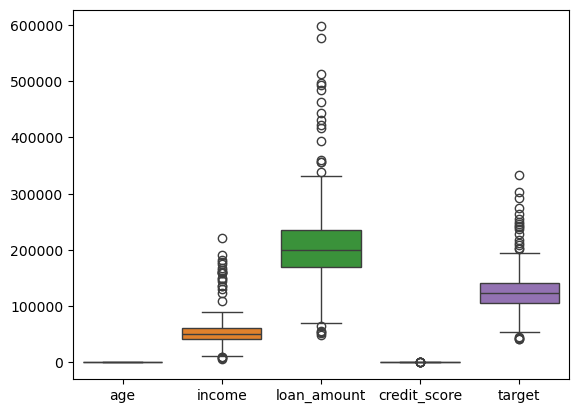

In [97]:
sns.boxplot(df)

In [98]:
##replace na vlaues with median

df['income'].fillna(df['income'].median(),inplace=True)


In [99]:
df['income'].isna().sum()

np.int64(0)

In [100]:
Q1=df['income'].quantile(0.25)
Q3=df['income'].quantile(0.75)
IQR=Q3-Q1
df=df[(df['income']>=Q1-1.5*IQR) & (df['income']<=Q3+1.5*IQR)]

<Axes: ylabel='income'>

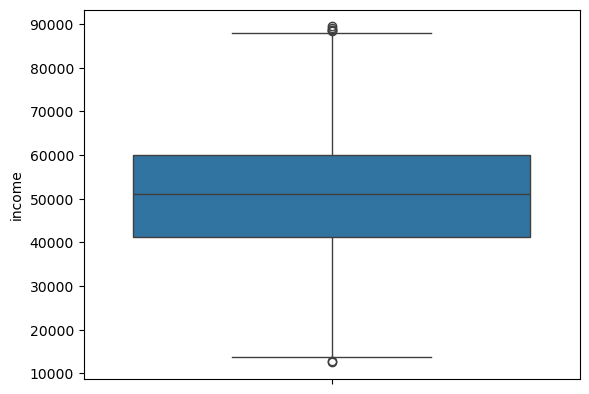

In [101]:
sns.boxplot(df['income'])

<Axes: xlabel='income', ylabel='Count'>

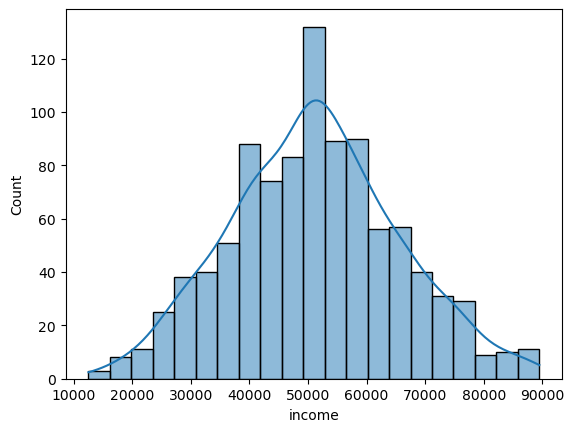

In [102]:
sns.histplot(df['income'],kde=True)

In [103]:
df


,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404
...,...,...,...,...,...,...,...
995,60,51119.925190,272663.033166,502.604714,Chennai,Salaried,155285.942941
996,64,36687.617333,133069.710014,730.751324,Bangalore,Self-Employed,65076.404995
997,62,43438.125495,234645.931152,747.044458,Hyderabad,Unemployed,126006.462108
998,35,60835.720367,169706.958962,628.847359,Bangalore,Unemployed,118101.789665


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 975 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              975 non-null    int64  
 1   income           975 non-null    float64
 2   loan_amount      945 non-null    float64
 3   credit_score     946 non-null    float64
 4   city             975 non-null    object 
 5   employment_type  975 non-null    object 
 6   target           975 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 60.9+ KB


In [105]:
df.isna().sum()

age                 0
income              0
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

<Axes: >

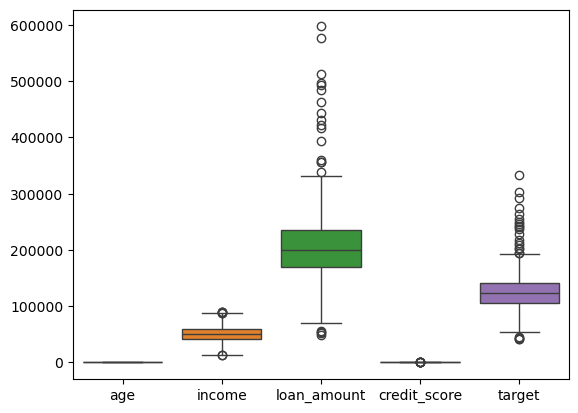

In [106]:
sns.boxplot(df)

In [107]:
df['loan_amount'].fillna(df['loan_amount'].median(),inplace=True)

In [108]:
Q1=df['loan_amount'].quantile(0.25)
Q3=df['loan_amount'].quantile(0.75)
IQR=Q3-Q1
df=df[(df['loan_amount']>=Q1-1.5*IQR) & (df['loan_amount']<=Q3+1.5*IQR)]

In [109]:
df['loan_amount'].isna().sum()

np.int64(0)

<Axes: ylabel='loan_amount'>

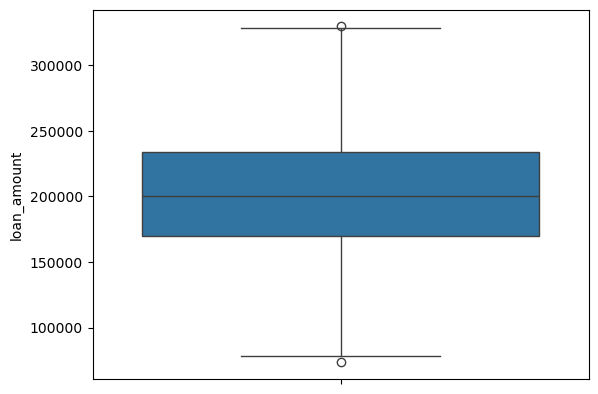

In [110]:
sns.boxplot(df['loan_amount'])

In [111]:
df.isna().sum()

age                 0
income              0
loan_amount         0
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [112]:
df['credit_score'].fillna(df['credit_score'].median(),inplace=True)

In [113]:
Q1=df['credit_score'].quantile(0.25)
Q3=df['credit_score'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['credit_score']>=lower_bound) & (df['credit_score']<=upper_bound)]

<Axes: >

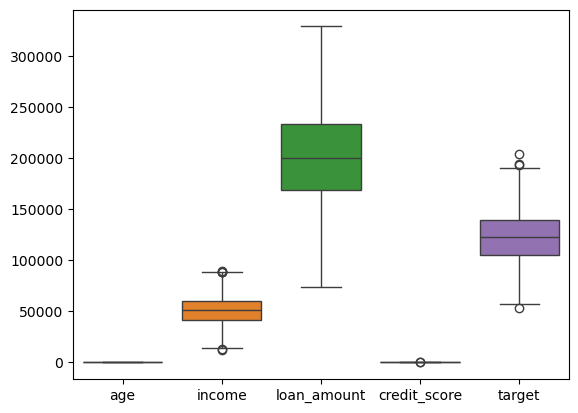

In [114]:
sns.boxplot(df)

In [115]:
##handles outliers by capping function
import numpy as np

def cap_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    column = np.where(column < lower_bound, lower_bound, column)
    column = np.where(column > upper_bound, upper_bound, column)

    return column
df['credit_score']=cap_outliers(df['credit_score'])
df['income']=cap_outliers(df['income'])
df['loan_amount']=cap_outliers(df['loan_amount'])


<Axes: >

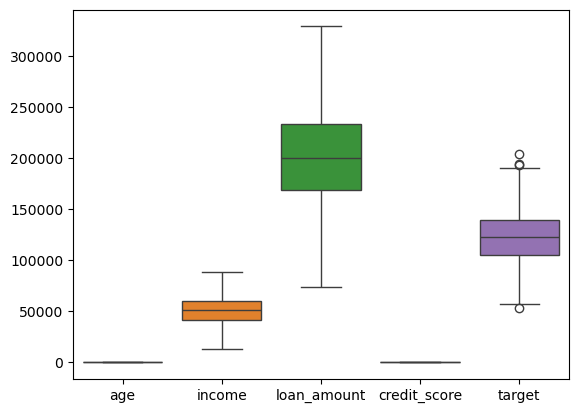

In [116]:
sns.boxplot(df)

In [117]:
df

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404
...,...,...,...,...,...,...,...
995,60,51119.925190,272663.033166,502.604714,Chennai,Salaried,155285.942941
996,64,36687.617333,133069.710014,730.751324,Bangalore,Self-Employed,65076.404995
997,62,43438.125495,234645.931152,747.044458,Hyderabad,Unemployed,126006.462108
998,35,60835.720367,169706.958962,628.847359,Bangalore,Unemployed,118101.789665


In [118]:
#import onehot encoder
from sklearn.preprocessing import OneHotEncoder
cat=['city','employment_type']
encoder=OneHotEncoder(sparse_output=False)
encoded_data=encoder.fit_transform(df[cat])

In [119]:
encoded_cols=encoder.get_feature_names_out(cat)
encoded_df=pd.DataFrame(encoded_data,columns=encoded_cols)
df=df.drop(cat,axis=1)
df=pd.concat([df,encoded_df],axis=1)

In [120]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56.0,25903.305196,286348.192562,789.476075,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69.0,53051.954538,180018.190719,596.334039,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46.0,38654.738821,211234.236288,611.531000,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32.0,28666.194356,246629.541594,710.171152,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60.0,40301.406736,129081.713353,622.900855,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [121]:
df.isna().sum()


age                              55
income                           55
loan_amount                      55
credit_score                     55
target                           55
city_Bangalore                   55
city_Chennai                     55
city_Hyderabad                   55
city_Mumbai                      55
employment_type_Salaried         55
employment_type_Self-Employed    55
employment_type_Unemployed       55
dtype: int64

In [151]:
## if column follows noral distribution we can use minmax scaler otherwise we can use a standard scaler
df

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56.0,0.171289,0.831519,2.084714,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69.0,0.530343,0.416155,-0.790430,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46.0,0.339933,0.538096,-0.564205,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32.0,0.207829,0.676363,0.904168,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60.0,0.361711,0.217179,-0.394952,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
937,67.0,0.590725,0.235127,-0.546086,84760.228822,0.0,1.0,0.0,0.0,1.0,0.0,0.0
938,68.0,0.596768,0.698771,-0.624432,145388.387522,1.0,0.0,0.0,0.0,0.0,1.0,0.0
939,36.0,0.702746,0.722653,-0.072016,159349.570995,0.0,0.0,1.0,0.0,0.0,0.0,1.0
940,38.0,0.417579,0.449407,0.452193,103868.799775,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [123]:
skew=df.drop(columns=['target']).skew()
skew

age                             -0.050663
income                           0.093584
loan_amount                      0.050450
credit_score                    -0.053735
city_Bangalore                   1.089263
city_Chennai                     1.108193
city_Hyderabad                   1.120941
city_Mumbai                      1.318842
employment_type_Salaried         0.775281
employment_type_Self-Employed    0.599308
employment_type_Unemployed       0.754416
dtype: float64

In [124]:
normal_skew_features=skew[skew==0].index.tolist()
positive_skew_features=skew[skew>0.5].index.tolist()
negative_skew_features=skew[skew<0.5].index.tolist()
print("Normal Skew Features:", normal_skew_features)
print("Positive Skew Features:", positive_skew_features)
print("Negative Skew Features:", negative_skew_features)

Normal Skew Features: []
Positive Skew Features: ['city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed']
Negative Skew Features: ['age', 'income', 'loan_amount', 'credit_score']


In [125]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler


In [126]:
scale=MinMaxScaler()

In [127]:
normal_skew=['income','loan_amount']
df[normal_skew]=scale.fit_transform(df[normal_skew])

In [128]:
df[normal_skew]

,income,loan_amount
0,0.171289,0.831519
1,0.530343,0.416155
2,0.339933,0.538096
3,0.207829,0.676363
4,0.361711,0.217179
...,...,...
849,NaN,NaN
864,NaN,NaN
873,NaN,NaN
903,NaN,NaN


In [129]:
scaler=StandardScaler()
df['credit_score']=scaler.fit_transform(df[['credit_score']])

In [130]:
df['credit_score']

0      2.084714
1     -0.790430
2     -0.564205
3      0.904168
4     -0.394952
         ...   
849         NaN
864         NaN
873         NaN
903         NaN
921         NaN
Name: credit_score, Length: 997, dtype: float64

In [131]:
df.dropna()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56.0,0.171289,0.831519,2.084714,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69.0,0.530343,0.416155,-0.790430,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46.0,0.339933,0.538096,-0.564205,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32.0,0.207829,0.676363,0.904168,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60.0,0.361711,0.217179,-0.394952,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
937,67.0,0.590725,0.235127,-0.546086,84760.228822,0.0,1.0,0.0,0.0,1.0,0.0,0.0
938,68.0,0.596768,0.698771,-0.624432,145388.387522,1.0,0.0,0.0,0.0,0.0,1.0,0.0
939,36.0,0.702746,0.722653,-0.072016,159349.570995,0.0,0.0,1.0,0.0,0.0,0.0,1.0
940,38.0,0.417579,0.449407,0.452193,103868.799775,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [132]:
df=df.dropna()

In [133]:
df.isna().sum()


age                              0
income                           0
loan_amount                      0
credit_score                     0
target                           0
city_Bangalore                   0
city_Chennai                     0
city_Hyderabad                   0
city_Mumbai                      0
employment_type_Salaried         0
employment_type_Self-Employed    0
employment_type_Unemployed       0
dtype: int64

In [134]:
df

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56.0,0.171289,0.831519,2.084714,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69.0,0.530343,0.416155,-0.790430,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46.0,0.339933,0.538096,-0.564205,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32.0,0.207829,0.676363,0.904168,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60.0,0.361711,0.217179,-0.394952,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
937,67.0,0.590725,0.235127,-0.546086,84760.228822,0.0,1.0,0.0,0.0,1.0,0.0,0.0
938,68.0,0.596768,0.698771,-0.624432,145388.387522,1.0,0.0,0.0,0.0,0.0,1.0,0.0
939,36.0,0.702746,0.722653,-0.072016,159349.570995,0.0,0.0,1.0,0.0,0.0,0.0,1.0
940,38.0,0.417579,0.449407,0.452193,103868.799775,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [135]:
#import train test split
from sklearn.model_selection import train_test_split
X=df.drop(columns=['target'])
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [137]:
#after splitting the data we can apply knn regression model
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 698408629.5755934


In [138]:
#find R2 score
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score:", r2)


R2 Score: -0.05257852878997804


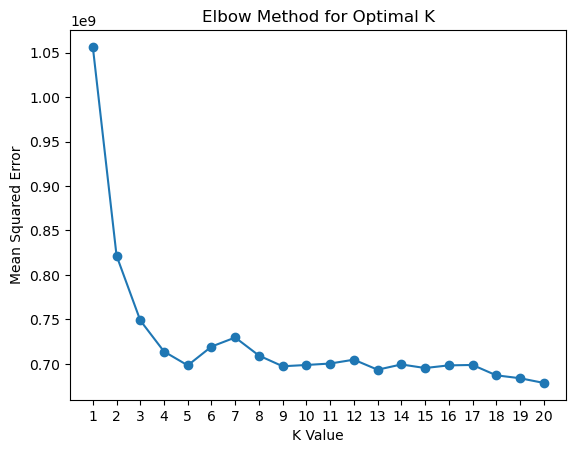

In [145]:
## use elbow method to find optimal k value
mse_values=[]
k_values=range(1,21)
for k in k_values:
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    mse=mean_squared_error(y_test,y_pred)
    mse_values.append(mse)
plt.plot(k_values,mse_values,marker='o')
plt.xlabel('K Value')
plt.ylabel('Mean Squared Error')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_values)
plt.show()


In [148]:
##use linear regression model to compare the performance of knn regression model
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
mse_lr=mean_squared_error(y_test,y_pred_lr)
print("Mean Squared Error for Linear Regression:", mse_lr)


Mean Squared Error for Linear Regression: 95933693.34637453


In [149]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score:", r2)
r2_lr=r2_score(y_test,y_pred_lr)
print("R2 Score for Linear Regression:", r2_lr)

R2 Score: -0.022875145448756795
R2 Score for Linear Regression: 0.8554173852844893


In [150]:
## use decision tree regression model to compare the performance of knn regression model
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)
mse_dt=mean_squared_error(y_test,y_pred_dt)
print("Mean Squared Error for Decision Tree Regression:", mse_dt)
r2_dt=r2_score(y_test,y_pred_dt)
print("R2 Score for Decision Tree Regression:", r2_dt)


Mean Squared Error for Decision Tree Regression: 228586363.52144733
R2 Score for Decision Tree Regression: 0.6554952387070786
